# Descan Correction for 4D-STEM (NBD / SPED) Data

## What this notebook does

In 4D-STEM (NBD or SPED mode), the electron beam is scanned across the sample
while a diffraction pattern (DP) is recorded at every scan (probe) position.
Ideally, the diffraction disk / direct beam should land on the **same detector
pixel** for every probe position, since diffraction geometry should not depend
on where the probe is on the sample. In practice, imperfect **scan alignmenet** in the scan coils and **descan
alignment** in the desscan coils causes the direct beam position to drift
smoothly across the detector as a function of probe (scan) position — this is
usually a close-to-linear "tilt" of the beam position across the field of
view.

This notebook corrects for that drift in five conceptual stages:

1. **Sample the direct-beam position** at a sparse set of user-chosen scan
   positions, using one of three interactive methods (Center of Mass, Manual
   Click, or Hough Circle detection).
2. **Clean** that sparse set of measurements by robustly rejecting outliers
   (mis-clicks, bad patterns, contamination, etc.).
3. **Fit a smooth plane** to the surviving points, giving a beam-position
   estimate for *every* scan pixel in the full field of view — not just the
   ones that were sampled.
4. **Shift** every diffraction pattern in the 4D dataset so the beam lands at
   a common reference position (the mean beam position).
5. **Save and verify** the corrected dataset (e.g. via the PACBED pattern,
   which should sharpen and re-center after correction).

## Why sample-and-fit instead of measuring every pattern directly?

`pyxem`'s
[`Diffraction2D.center_direct_beam`](https://pyxem.readthedocs.io/en/stable/reference/generated/pyxem.signals.Diffraction2D.center_direct_beam.html)
estimates the beam position **independently, pattern-by-pattern**, using a
per-pattern estimator (`cross_correlate`, `blur`, `interpolate`, or
`center_of_mass`) and then shifts each pattern to the detector center.

That approach works well when every single diffraction pattern has a clean,
unambiguous direct beam disk. For crystalline NBD/SPED data this assumption
often breaks down:

- Strong Bragg disks can be as bright as, overlap with, or even outshine the
  direct beam, so per-pattern estimators can lock onto the wrong disk.
- Vacuum, amorphous, or strongly diffracting regions of the scan may have a
  weak, saturated, or missing direct beam.
- Per-pattern noise means the resulting shift map is itself noisy, and a
  physically smooth (near-linear) descan drift gets "fitted" with a
  spatially-incoherent, per-pixel correction.

This notebook instead exploits the fact that **descan error is a smooth,
slowly-varying function of scan position** (a property of the scan coil
alignment, not of the sample). Instead of trusting every pattern, it:

- lets the user hand-pick a modest number of scan positions where the beam
  center is unambiguous (e.g. vacuum, or low-index zone axis with a clear
  central disk),
- statistically rejects any of those points that don't agree with the
  others (`remove_plane_outliers`), and
- fits a single smooth plane through the survivors, which is then evaluated
  at *every* scan position.

The result is a descan-correction map that is robust to occasional bad
patterns and does not require every single diffraction pattern to have a
cleanly resolvable direct beam — only a representative subset does. This
tends to be more robust than a purely per-pattern approach for beam-sensitive
or strongly diffracting crystalline samples, at the cost of requiring some
manual point selection and the assumption that the true descan error is well
described by a plane (a good approximation for most descan misalignments,
but not for higher-order/non-linear distortions).

`pyxem` does provide the building blocks to do something similar — see the
**Appendix** at the end of this notebook for a direct comparison and for how
the two approaches could be combined.

## Imports

In [1]:
import os

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.widgets import RectangleSelector

from scipy.ndimage import center_of_mass, gaussian_filter, shift
from scipy.linalg import lstsq
from skimage import exposure
from skimage.feature import canny
from skimage.filters import gaussian
from skimage.transform import hough_circle, hough_circle_peaks

import hyperspy.api as hs
from tqdm.notebook import tqdm

%matplotlib widget

## Load the 4D-STEM Dataset

Loads a `.hspy` file containing a 4D dataset with shape
`(scan_x, scan_y, detector_x, detector_y)`. Update `path` and `file_name` to
point at your dataset.

In [ ]:
server_path = '/server/'

# Path to the dataset (Windows-style path is converted to a POSIX path below)
path = r"Z:\LNO"
file_name = 'LNO.hspy'

formatted_path = '/'.join(path.split('\\')[1:]) + '/'
file_sub_path = server_path + formatted_path
file_path = file_sub_path + file_name

data_cube = hs.load(file_path)
data_cube = data_cube.data  # work directly with the underlying numpy array
Nx, Ny, dp_x_size, dp_y_size = data_cube.shape

print("Dataset shape:", data_cube.shape)

/home/ahmedsha/.conda/envs/stem/lib/python3.11/site-packages/rsciio/utils/tools.py:93: VisibleDeprecationWarning: ensure_directory has been moved to `rsciio.utils.path` and will be removed from `rsciio.utils.tools` in version 1.0.
  warnings.warn(message, VisibleDeprecationWarning)
/home/ahmedsha/.conda/envs/stem/lib/python3.11/site-packages/rsciio/utils/tools.py:93: VisibleDeprecationWarning: overwrite has been moved to `rsciio.utils.path` and will be removed from `rsciio.utils.tools` in version 1.0.
  warnings.warn(message, VisibleDeprecationWarning)
/home/ahmedsha/.conda/envs/stem/lib/python3.11/site-packages/rsciio/utils/tools.py:93: VisibleDeprecationWarning: get_file_handle has been moved to `rsciio.utils.file` and will be removed from `rsciio.utils.tools` in version 1.0.
  warnings.warn(message, VisibleDeprecationWarning)
/home/ahmedsha/.conda/envs/stem/lib/python3.11/site-packages/rsciio/utils/rgb_tools.py:46: VisibleDeprecationWarning: The module `rsciio.utils.rgb_tools` has b

Dataset shape: (200, 200, 256, 256)


/home/ahmedsha/.conda/envs/stem/lib/python3.11/site-packages/rsciio/utils/tools.py:93: VisibleDeprecationWarning: append2pathname has been moved to `rsciio.utils.path` and will be removed from `rsciio.utils.tools` in version 1.0.
  warnings.warn(message, VisibleDeprecationWarning)
/home/ahmedsha/.conda/envs/stem/lib/python3.11/site-packages/rsciio/utils/tools.py:93: VisibleDeprecationWarning: incremental_filename has been moved to `rsciio.utils.path` and will be removed from `rsciio.utils.tools` in version 1.0.
  warnings.warn(message, VisibleDeprecationWarning)


## Data Visualization

### Scan Overview Image

Collapse the two detector dimensions (mean over the diffraction pattern) to
get a real-space navigation image of the scan.

In [3]:
I_ALL = data_cube.mean(axis=(2, 3))
I_ALL = I_ALL / I_ALL.max()

### Interactive Diffraction Pattern Viewer

Click anywhere on the overview image (top-left) to inspect the raw
diffraction pattern at that scan position, along with a Gaussian-smoothed and
a gamma-adjusted version — useful for judging where the direct beam is
clearly visible before picking points for center-finding below.

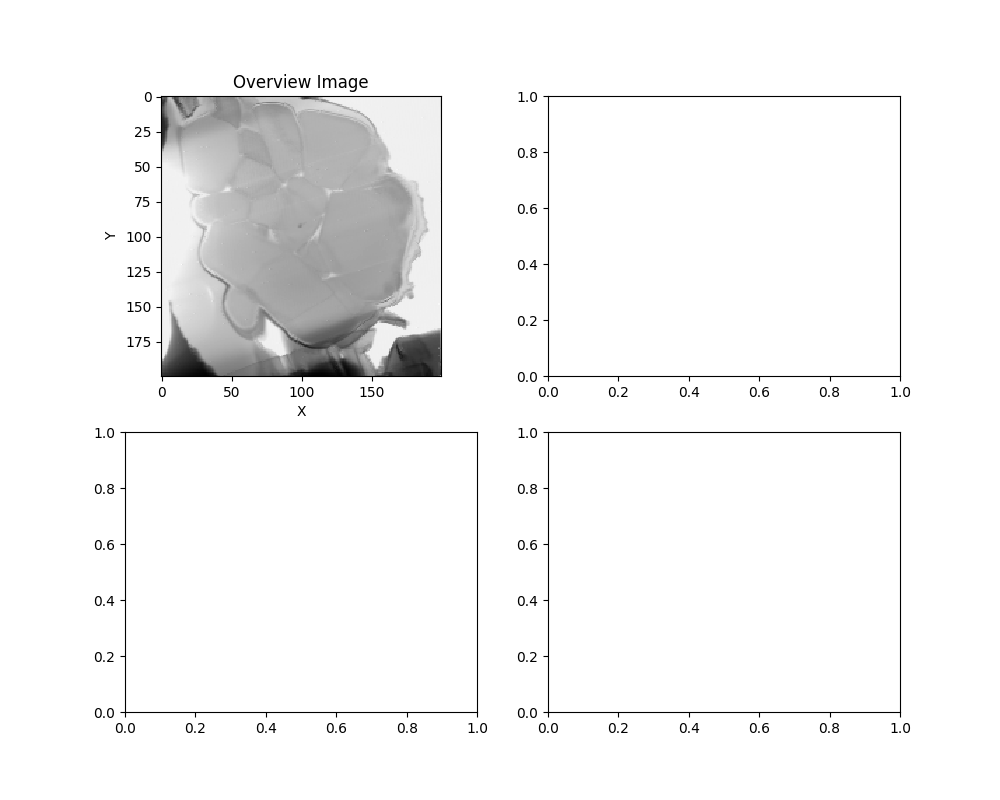

In [4]:
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.figsize'] = (10, 8)

# Preprocessing settings for the DP preview
square_apply = True
if_log = True
gaussian_sigma = 1.0
gamma_range = (0.0, 0.15)

fig, axs = plt.subplots(2, 2)
ax_overview, ax_dp, ax_gauss, ax_gamma = axs[0, 0], axs[0, 1], axs[1, 0], axs[1, 1]

ax_overview.imshow(I_ALL, aspect='equal', interpolation='nearest')
ax_overview.set_title('Overview Image')
ax_overview.set_xlabel('X')
ax_overview.set_ylabel('Y')

def on_click(event):
    if event.inaxes is not ax_overview or event.button != 1:
        return

    x, y = event.xdata, event.ydata
    xi, yi = int(round(x)), int(round(y))

    ax_overview.plot(x, y, 'r+')
    fig.canvas.draw_idle()

    DP = data_cube[yi, xi, :, :].astype(float)
    if if_log:
        DP = np.log(DP + 1)
    DP[DP < 0] = 0
    DP = np.where(np.isnan(DP) | np.isinf(DP), np.nanmean(DP), DP)
    if square_apply:
        DP = DP ** 2

    B = gaussian_filter(DP, sigma=gaussian_sigma)
    J = B / B.max()
    J = exposure.rescale_intensity(J, in_range=gamma_range, out_range=(0, 1))

    for ax, img, title in [(ax_dp, DP, 'Original DP'),
                            (ax_gauss, B, 'After Gaussian Filter'),
                            (ax_gamma, J, 'After Gamma Adjustment')]:
        ax.clear()
        ax.imshow(img, aspect='equal', interpolation='nearest')
        ax.set_title(title)
        ax.axis('off')

fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()

## Step 1: Locate the Direct-Beam Center at Selected Scan Positions

All three tools below share the same interaction pattern:

1. Click a point on the **overview image** (left panel) to load that scan
   position's diffraction pattern into the right panel.
2. Interact with the diffraction pattern (draw a region, or click) to record
   the beam center for that scan position into two 2D arrays,
   `descan_x` and `descan_y` — the coordinates of the beam center, indexed by
   scan position `(y, x)`. Positions that are never visited stay at `0`,
   which is later converted to `NaN` before fitting.

You only need to sample a modest number of scan positions (tens, not
thousands) — enough to constrain the plane fit in the next step. Prefer
positions spread across the whole scan area, and where the direct beam is
unambiguous (e.g. vacuum, or a low-diffraction area of the sample).

Only run **one** of the three method cells below per correction pass (they
each (re)initialize `descan_x` / `descan_y`).

### Method A — Center of Mass (COM) within a Hand-Drawn ROI

Draw a rectangle around the direct beam in the diffraction pattern panel.
The intensity-weighted center of mass is computed **only inside that
rectangle**, which excludes bright Bragg spots or contamination elsewhere in
the pattern. This is the most robust of the three methods when the direct
beam is a diffuse blob without sharp edges, since COM does not require a
well-defined boundary — it only requires that stray intensity be excluded
from the ROI.

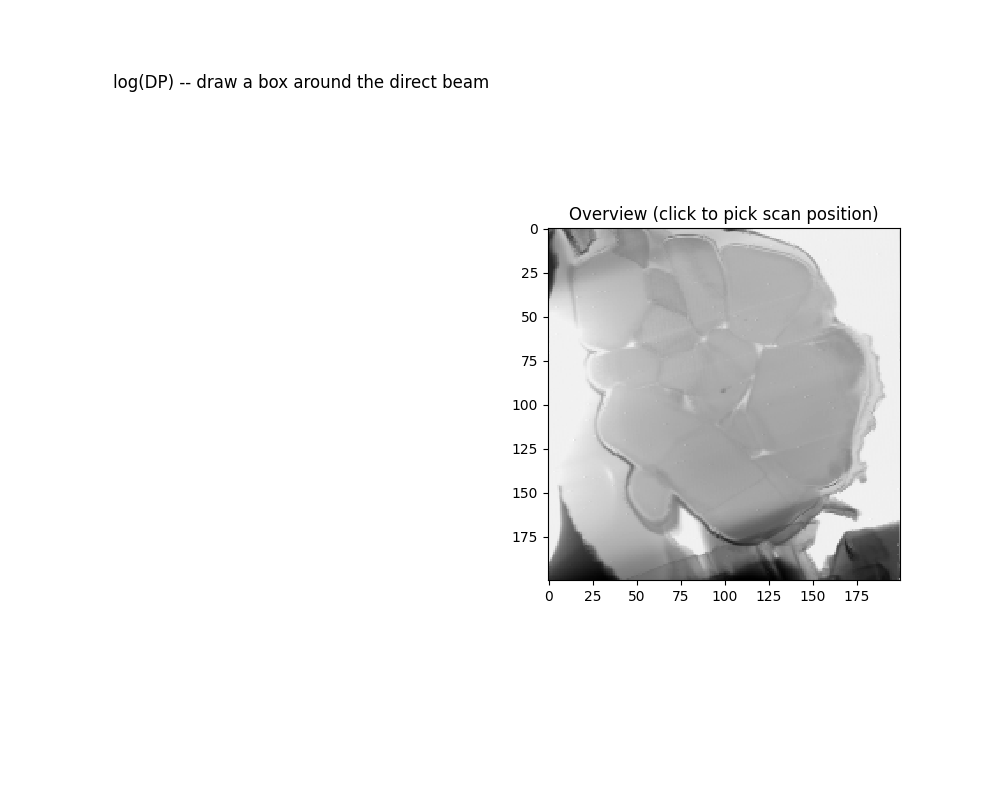

In [5]:
image_size_x, image_size_y, _, _ = data_cube.shape
descan_x = np.zeros((image_size_x, image_size_y))
descan_y = np.zeros((image_size_x, image_size_y))

fig, (ax_dp, ax_overview) = plt.subplots(1, 2)
ax_overview.imshow(I_ALL, aspect='equal', interpolation='nearest')
ax_overview.set_title('Overview (click to pick scan position)')
ax_dp.set_title('log(DP) -- draw a box around the direct beam')
ax_dp.axis('off')

current_click = {}

def onselect(eclick, erelease):
    '''Compute the center of mass of the DP inside the drawn rectangle.'''
    if 'DP' not in current_click:
        return

    DP = current_click['DP']
    y0, x0 = current_click['yx']

    cx, cy = (eclick.xdata + erelease.xdata) / 2, (eclick.ydata + erelease.ydata) / 2
    w, h = abs(erelease.xdata - eclick.xdata), abs(erelease.ydata - eclick.ydata)

    yy, xx = np.mgrid[0:DP.shape[0], 0:DP.shape[1]]
    mask = (((xx - cx) / (w / 2)) ** 2 + ((yy - cy) / (h / 2)) ** 2) <= 1

    com_x, com_y = center_of_mass(DP * mask)
    descan_x[y0, x0] = com_x
    descan_y[y0, x0] = com_y

    ax_dp.add_patch(patches.Ellipse((cx, cy), w, h, edgecolor='r', facecolor='none', linewidth=1.5))
    fig.canvas.draw_idle()

selector = RectangleSelector(ax_dp, onselect, useblit=False, button=[1],
                              minspanx=0, minspany=0, spancoords='data', interactive=False)

def on_click(event):
    if event.inaxes is not ax_overview or event.button != 1:
        return

    y_click, x_click = int(round(event.ydata)), int(round(event.xdata))
    current_click['yx'] = (y_click, x_click)

    DP = data_cube[y_click, x_click, :, :].astype(float)
    DP = np.log(DP + 1) ** 2
    current_click['DP'] = DP

    ax_overview.plot(event.xdata, event.ydata, marker='o', color='red',
                      markersize=6, markeredgecolor='black')

    ax_dp.clear()
    ax_dp.imshow(DP, aspect='equal', interpolation='nearest')
    ax_dp.set_title('log(DP) -- draw a box around the direct beam')
    ax_dp.axis('on')
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()

### Method B — Direct Manual Click

Click directly on the center of the direct beam in the diffraction pattern
panel. This is the fastest and most transparent method (what you click is
what you get), which makes it a good sanity check against the other two
methods, but it is limited by pixel-level manual precision and cannot be
sub-pixel accurate.

In [ ]:
image_size_x, image_size_y, _, _ = data_cube.shape
descan_x = np.zeros((image_size_x, image_size_y))
descan_y = np.zeros((image_size_x, image_size_y))

fig, (ax_dp, ax_overview) = plt.subplots(1, 2)
ax_overview.imshow(I_ALL, aspect='equal', interpolation='nearest')
ax_overview.set_title('Overview (click to pick scan position)')
ax_dp.set_title('DP (click to mark the beam center)')
ax_dp.axis('off')

current_click = {}

def on_overview_click(event):
    if event.inaxes is not ax_overview or event.button != 1:
        return

    y_click, x_click = int(round(event.ydata)), int(round(event.xdata))
    current_click['yx'] = (y_click, x_click)

    DP = data_cube[y_click, x_click].astype(float)
    DP = (DP + 1) ** 2
    current_click['DP'] = DP

    ax_overview.plot(event.xdata, event.ydata, 'ro', markersize=6, markeredgecolor='black')

    ax_dp.clear()
    ax_dp.imshow(DP, aspect='equal', interpolation='nearest')
    ax_dp.set_title('DP (click to mark the beam center)')
    ax_dp.axis('on')
    fig.canvas.draw_idle()

def on_dp_click(event):
    if event.inaxes is not ax_dp or event.button != 1 or 'yx' not in current_click:
        return

    cx, cy = event.xdata, event.ydata
    y0, x0 = current_click['yx']
    descan_x[y0, x0] = cx
    descan_y[y0, x0] = cy

    ax_dp.plot(cx, cy, 'go', markersize=7, markeredgecolor='black')
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', on_overview_click)
fig.canvas.mpl_connect('button_press_event', on_dp_click)
plt.show()

### Method C — Automatic Circle Detection (Canny Edges + Hough Transform)

Draw a rough region of interest around the direct beam; within that ROI the
edges are detected (Canny) and a circle is fit to them via the Hough circle
transform. This is the most automated and most precise (sub-pixel, symmetric)
of the three when the direct beam has a clean circular edge, but it is
sensitive to the expected radius range (`min_r`, `max_r`) and can fail
silently ("No circle detected") if the beam is defocused, elliptical, or
overlaps other disks.

In [ ]:
image_size_x, image_size_y, _, _ = data_cube.shape
descan_x = np.zeros((image_size_x, image_size_y))
descan_y = np.zeros((image_size_x, image_size_y))

fig, (ax_dp, ax_overview) = plt.subplots(1, 2)
ax_overview.imshow(I_ALL, aspect='equal', interpolation='nearest')
ax_overview.set_title('Overview (click to pick scan position)')
ax_dp.set_title('DP (draw ROI around the direct beam)')
ax_dp.axis('off')

current_click = {}

# Expected direct-beam radius range in pixels -- tune to your camera length / binning
min_r, max_r = 40, 48
radii = np.arange(min_r, max_r, 2)

def onselect(eclick, erelease):
    if 'DP' not in current_click:
        return

    DP = current_click['DP']
    y0, x0 = current_click['yx']

    x1, x2 = sorted([int(eclick.xdata), int(erelease.xdata)])
    y1, y2 = sorted([int(eclick.ydata), int(erelease.ydata)])
    roi = DP[y1:y2, x1:x2]

    roi_smooth = gaussian(roi, sigma=1)
    edges = canny(roi_smooth, sigma=4)

    hough_res = hough_circle(edges, radii)
    accums, cx, cy, rad = hough_circle_peaks(hough_res, radii, total_num_peaks=1)

    if len(cx) == 0:
        print("No circle detected")
        return

    cx_global, cy_global, r_global = cx[0] + x1, cy[0] + y1, rad[0]
    descan_x[y0, x0] = cx_global
    descan_y[y0, x0] = cy_global

    ax_dp.add_patch(patches.Circle((cx_global, cy_global), r_global,
                                    edgecolor='lime', facecolor='none', linewidth=2))
    ax_dp.plot(cx_global, cy_global, 'r+', markersize=12)
    fig.canvas.draw_idle()

selector = RectangleSelector(ax_dp, onselect, useblit=False, button=[1],
                              spancoords='data', interactive=False)

def on_overview_click(event):
    if event.inaxes is not ax_overview or event.button != 1:
        return

    y_click, x_click = int(round(event.ydata)), int(round(event.xdata))
    current_click['yx'] = (y_click, x_click)

    DP = data_cube[y_click, x_click].astype(float)
    DP = np.log(DP + 1) ** 2
    current_click['DP'] = DP

    ax_overview.plot(event.xdata, event.ydata, 'ro', markersize=6, markeredgecolor='black')

    ax_dp.clear()
    ax_dp.imshow(DP, aspect='equal', interpolation='nearest')
    ax_dp.set_title('DP (draw ROI around the direct beam)')
    ax_dp.axis('on')
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', on_overview_click)
plt.show()

## Step 2: Visualize the Sparse Descan Map

`descan_x` / `descan_y` are mostly zero (unvisited scan positions). Convert
the zeros to `NaN` so they are excluded from the plane fit, and plot what has
been sampled so far.

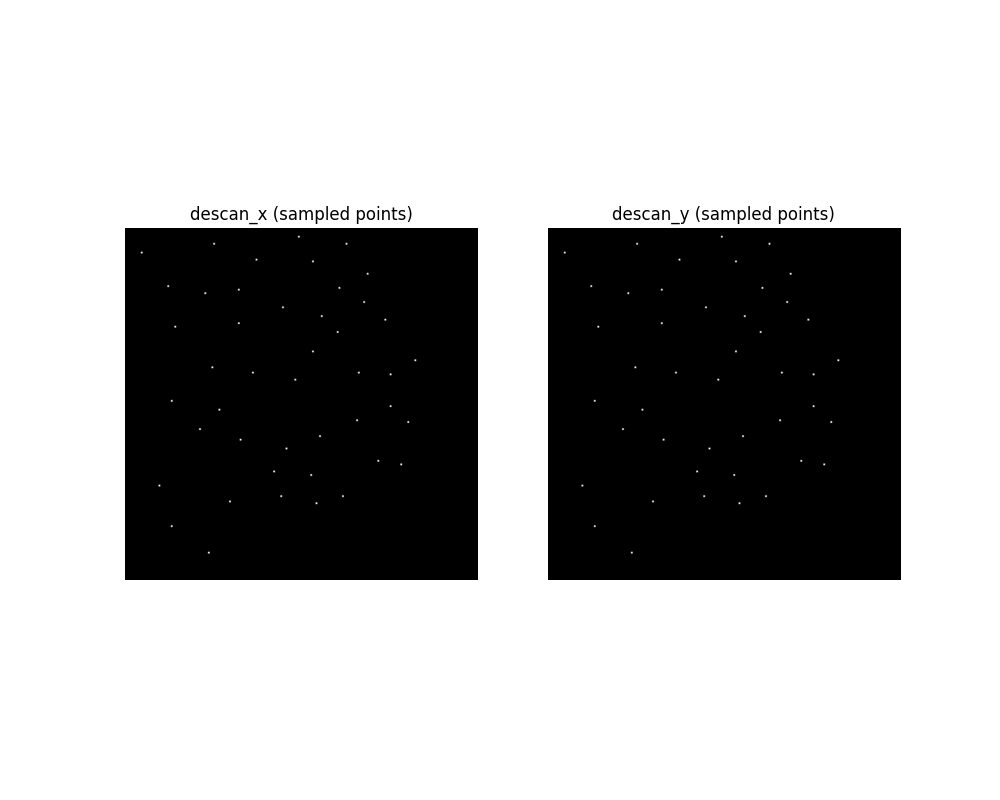

In [6]:
descan_x[descan_x == 0] = np.nan
descan_y[descan_y == 0] = np.nan

fig, ax = plt.subplots(1, 2)
ax[0].imshow(np.nan_to_num(descan_x, nan=0))
ax[0].set_title('descan_x (sampled points)')
ax[0].axis('off')
ax[1].imshow(np.nan_to_num(descan_y, nan=0))
ax[1].set_title('descan_y (sampled points)')
ax[1].axis('off')
plt.show()

## Step 3: Robust Outlier Removal

Manually- or automatically-picked centers can occasionally be wrong (a
mis-click, a pattern with no visible direct beam, a failed circle fit).
Before fitting a plane through the sampled points, `remove_plane_outliers`:

1. fits a first-pass plane to all sampled (non-NaN) points,
2. computes each point's residual from that plane,
3. converts residuals to a robust z-score using the **median absolute
   deviation (MAD)** rather than the standard deviation (so a few bad points
   don't skew the threshold), and
4. discards (sets to `NaN`) any point whose robust z-score exceeds `thresh`.

This is applied independently to `descan_x` and `descan_y`.

In [7]:
def remove_plane_outliers(XX, YY, BB, thresh=4.0):
    '''Fit a plane to BB(XX, YY) and flag points that deviate from it.

    Outliers (robust z-score > thresh) are replaced with NaN. NaNs already
    present in BB (unsampled scan positions) are ignored throughout.
    '''
    BB_clean = BB.copy()
    valid = ~np.isnan(BB_clean)

    if np.count_nonzero(valid) < 3:
        return BB_clean, np.zeros_like(BB_clean, dtype=bool)

    x, y, z = XX[valid], YY[valid], BB_clean[valid]
    A = np.column_stack((np.ones_like(x), x, y))
    coeffs, *_ = lstsq(A, z)

    resid = z - (coeffs[0] + coeffs[1] * x + coeffs[2] * y)
    med = np.median(resid)
    mad = np.median(np.abs(resid - med))
    if mad == 0:
        return BB_clean, np.zeros_like(BB_clean, dtype=bool)

    robust_score = np.abs(resid - med) / (1.4826 * mad)
    outlier_idx = robust_score > thresh

    outlier_mask = np.zeros_like(BB_clean, dtype=bool)
    outlier_mask[valid] = outlier_idx
    BB_clean[outlier_mask] = np.nan

    return BB_clean, outlier_mask

In [8]:
# Coordinate grid matching descan_x / descan_y (1-based, matches the MATLAB
# convention used in the original fitting routine below)
nrows, ncols = descan_x.shape
row_inds, col_inds = np.arange(1, nrows + 1), np.arange(1, ncols + 1)
XX, YY = np.meshgrid(row_inds, col_inds, indexing='ij')

imagex_clean, out_mask_x = remove_plane_outliers(XX, YY, descan_x, thresh=4.0)
imagey_clean, out_mask_y = remove_plane_outliers(XX, YY, descan_y, thresh=4.0)

print("descan_x: valid points after cleaning:", np.count_nonzero(~np.isnan(imagex_clean)))
print("descan_y: valid points after cleaning:", np.count_nonzero(~np.isnan(imagey_clean)))

descan_x: valid points after cleaning: 45
descan_y: valid points after cleaning: 45


## Step 4: Fit a Smooth Plane Across the Full Scan Grid

This is the key step that lets a *sparse* set of sampled points correct
*every* scan position: `createSurfaceFits` fits a first-order polynomial
(plane) `z = c0 + c1*x + c2*y` by least squares through the cleaned points,
then evaluates that plane at every `(x, y)` in the full scan grid, giving a
complete descan-correction map (`descan_bg_x`, `descan_bg_y`).

**Note:** the fit uses `imagex_clean` / `imagey_clean` (the outlier-cleaned
maps from Step 3), not the raw sampled points, so mis-clicks or failed
detections excluded in Step 3 do not influence the fit.

In [9]:
def createSurfaceFits(YY, XX, BB):
    '''Fit a plane z = c0 + c1*x + c2*y to BB(XX, YY), ignoring NaNs.

    Returns a callable `model_eval(X, Y)` for evaluating the fitted plane
    anywhere, the fit coefficients, and goodness-of-fit metrics.
    '''
    XX, YY, BB = np.asarray(XX), np.asarray(YY), np.asarray(BB)
    mask = ~np.isnan(BB)
    XX_flat, YY_flat, BB_flat = XX[mask].ravel(), YY[mask].ravel(), BB[mask].ravel()

    n = len(BB_flat)
    if n < 3:
        raise ValueError("Insufficient non-NaN data points for fitting (minimum 3 required)")

    A = np.column_stack((np.ones(n), XX_flat, YY_flat))
    coeffs, residues, rank, _ = lstsq(A, BB_flat)

    # lstsq returns residues as an empty array when the system is
    # under-/well-determined; fall back to 0.0 in that case
    residues = np.atleast_1d(residues)
    sse = float(residues[0]) if residues.size else 0.0

    mean_BB = np.mean(BB_flat)
    sst = np.sum((BB_flat - mean_BB) ** 2)
    rsquare = 1 - sse / sst if sst != 0 else 1
    adjrsquare = 1 - (1 - rsquare) * (n - 1) / (n - 3) if n > 3 else rsquare
    rmse = np.sqrt(sse / (n - 3)) if n > 3 else 0.0

    def model_eval(XX_eval, YY_eval):
        return coeffs[0] + coeffs[1] * XX_eval + coeffs[2] * YY_eval

    gof = {'sse': sse, 'rsquare': rsquare, 'adjrsquare': adjrsquare, 'rmse': rmse}
    return model_eval, coeffs, gof

In [10]:
nrows, ncols = descan_x.shape
row_inds, col_inds = np.arange(1, nrows + 1), np.arange(1, ncols + 1)
XX, YY = np.meshgrid(row_inds, col_inds, indexing='ij')

fittedmodel_x, coeffs_x, gof_x = createSurfaceFits(YY, XX, imagex_clean)
descan_bg_x = fittedmodel_x(XX, YY)

fittedmodel_y, coeffs_y, gof_y = createSurfaceFits(YY, XX, imagey_clean)
descan_bg_y = fittedmodel_y(XX, YY)

print(f"descan_x plane fit: R^2 = {gof_x['rsquare']:.4f}, RMSE = {gof_x['rmse']:.3f} px")
print(f"descan_y plane fit: R^2 = {gof_y['rsquare']:.4f}, RMSE = {gof_y['rmse']:.3f} px")

descan_x plane fit: R^2 = 0.9246, RMSE = 0.396 px
descan_y plane fit: R^2 = 0.9484, RMSE = 0.389 px


## Step 5: Visualize the Fitted Descan Planes

`descan_bg_x` / `descan_bg_y` now hold a smooth, full-field prediction of the
beam center at every scan position.

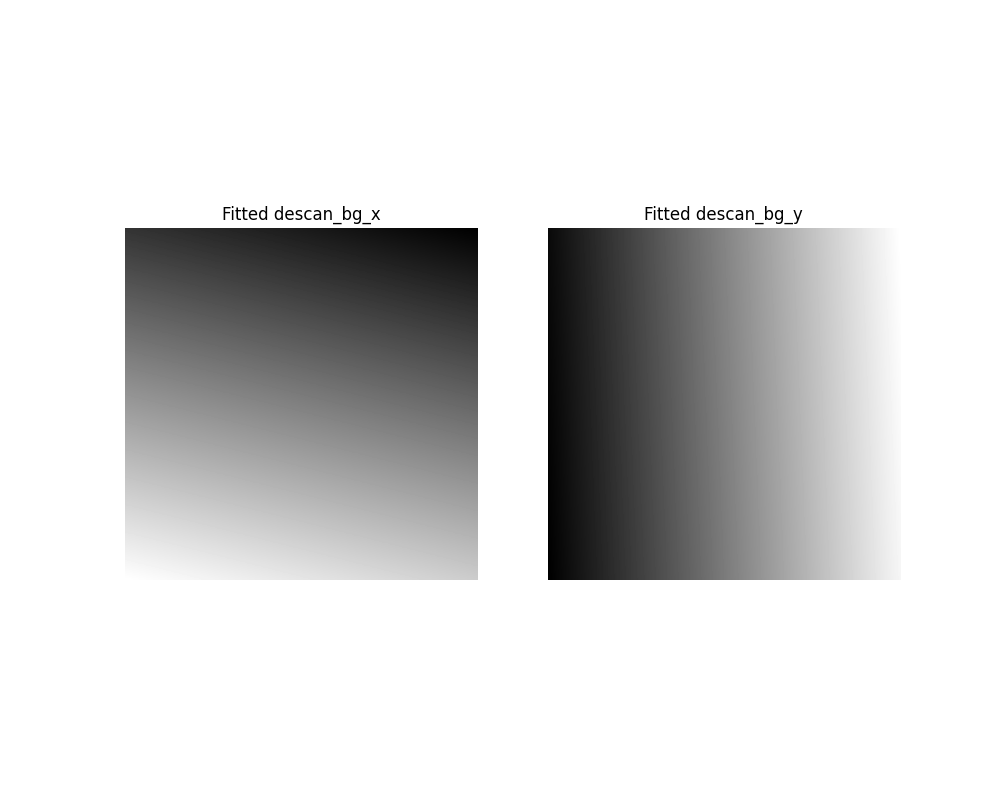

In [11]:
fig, ax = plt.subplots(1, 2)
im0 = ax[0].imshow(descan_bg_x)
ax[0].set_title('Fitted descan_bg_x')
ax[0].axis('off')
im1 = ax[1].imshow(descan_bg_y)
ax[1].set_title('Fitted descan_bg_y')
ax[1].axis('off')
plt.show()

## Step 6: Apply the Descan Correction

For every scan position, shift the diffraction pattern by the difference
between the global mean beam position and the *fitted* local beam position
at that scan pixel (not the raw sampled value), so every pattern ends up
centered at the same reference point.

In [12]:
# Global reference position: mean of the sampled (pre-outlier-removal) COMs
descan_x_mean = np.nanmean(descan_x)
descan_y_mean = np.nanmean(descan_y)

X, Y, Ny_det, Nx_det = data_cube.shape
data_cube_corrected = np.zeros_like(data_cube)

for ix in tqdm(range(X), desc="Descan correction over scan-X"):
    for iy in range(Y):
        DP = data_cube[ix, iy, :, :].astype(float)

        com_x = descan_bg_x[ix, iy]
        com_y = descan_bg_y[ix, iy]

        shift_y = descan_y_mean - com_y
        shift_x = descan_x_mean - com_x

        data_cube_corrected[ix, iy, :, :] = shift(
            DP, shift=(shift_x, shift_y), order=1, mode='nearest'
        )

Descan correction over scan-X:   0%|          | 0/200 [00:00<?, ?it/s]

## Step 7: Save the Corrected Dataset

Wrap the corrected array in a HyperSpy `Signal2D`, copy over the original
axes/metadata (loaded lazily so the full dataset isn't read twice), and save
as `.hspy`.

In [14]:
data_cube_corrected = hs.signals.Signal2D(data_cube_corrected)

# Re-attach the original calibration / metadata (loaded lazily to avoid
# reading the whole dataset again just for the axes manager)
data_cube_for_axis = hs.load(file_path, lazy=True)
data_cube_corrected.axes_manager = data_cube_for_axis.axes_manager.deepcopy()

name, extension = os.path.splitext(file_name)
data_cube_corrected.save(file_sub_path + name + "_dscan_corrected", overwrite=True)

print("Descan-corrected 4D dataset saved as:", name + "_dscan_corrected.hspy")

Descan-corrected 4D dataset saved as: TD022_LNO_850C_23032023_200x200_12_5nm_100ms_40cm_45d_converted_new_4D_Dataset_binned_2_dscan_corrected.hspy


## Step 8: Verify the Correction

Two quick sanity checks:

1. Re-run the interactive DP viewer on `data_cube_corrected` and confirm the
   beam sits at the same detector pixel regardless of scan position.
2. Compare the **PACBED** (Position-Averaged Convergent-Beam Electron
   Diffraction pattern — the mean diffraction pattern over the whole scan)
   before and after correction. Descan error blurs/smears the PACBED because
   it averages patterns whose beam position shifts across the field of view;
   after a correct descan correction the PACBED should be visibly sharper
   and more symmetric.

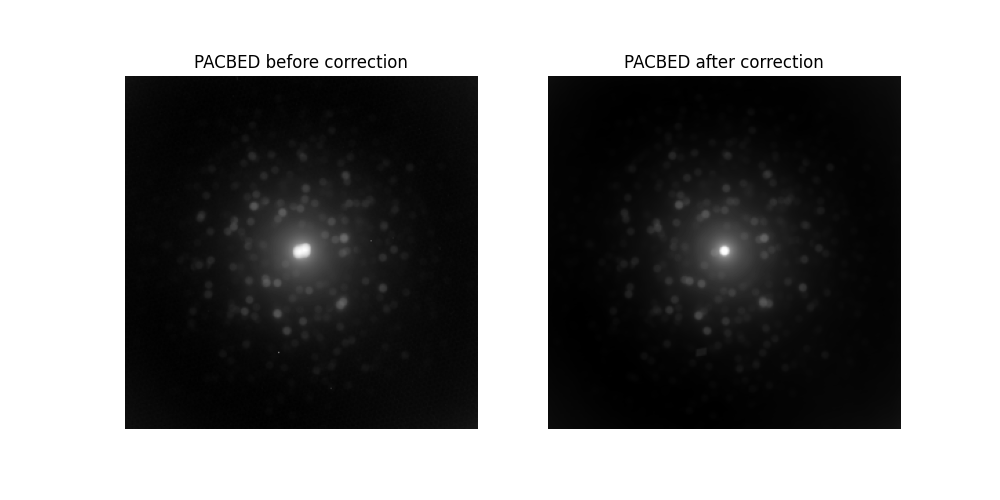

In [15]:
pacbed_before = np.log(data_cube.mean(axis=(0, 1)) + 1)
pacbed_after = np.log(data_cube_corrected.data.mean(axis=(0, 1)) + 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(pacbed_before)
ax[0].set_title('PACBED before correction')
ax[0].axis('off')
ax[1].imshow(pacbed_after)
ax[1].set_title('PACBED after correction')
ax[1].axis('off')
plt.show()

## Appendix: Comparison with `pyxem.signals.Diffraction2D.center_direct_beam`

[`center_direct_beam`](https://pyxem.readthedocs.io/en/stable/reference/generated/pyxem.signals.Diffraction2D.center_direct_beam.html)
estimates the direct-beam position **independently for every diffraction
pattern** using one of `method={'cross_correlate', 'blur', 'interpolate',
'center_of_mass'}`, then shifts each pattern to the detector center
(optionally with sub-pixel interpolation).

| | This notebook | `pyxem.center_direct_beam` (default use) |
|---|---|---|
| **Sampling** | Sparse, user-selected scan positions | Every scan position, automatically |
| **Center estimate per point** | Chosen interactively (COM / manual / Hough) with visual confirmation | One automatic estimator applied uniformly to the whole dataset |
| **Outlier handling** | Explicit robust (MAD-based) rejection before fitting | None built in — a single bad pattern shifts by whatever the estimator returns |
| **Model of the descan error** | Explicitly assumes a smooth plane across scan position, and enforces it via a least-squares fit | None by default — each pattern is corrected to its own estimated center, with no cross-pattern smoothness constraint |
| **Robustness on crystalline/strong-diffraction data** | High — only needs a subset of patterns to have an unambiguous beam | Lower — every pattern needs the estimator to correctly find the direct beam, which is hard when Bragg disks are bright, overlapping, or the direct beam is weak/absent |
| **Effort** | Manual point-picking required | Fully automatic, one function call |
| **Speed** | Slower (interactive + explicit Python loop over patterns) | Fast, vectorized/lazy-friendly |

**Why the plane-fit approach can be superior for descan correction specifically:**
descan misalignment is a property of the microscope's scan/de-scan coils, not
of the sample, so — to first order — it is a smooth, close-to-linear function
of scan position. Fitting that global, physically-motivated model through a
robust, outlier-cleaned sample of points is less sensitive to individual bad
patterns than measuring and correcting each pattern independently, which is
especially valuable for NBD/SPED data where many individual patterns contain
strong Bragg disks that can confuse a naive per-pattern beam finder.

**Where `pyxem` is preferable:** if the direct beam is reliably the brightest,
most well-defined feature in *every* pattern (e.g. amorphous samples, or
diffuse/incoherent imaging), `center_direct_beam` is faster, fully automatic,
and needs no manual point selection. It is also the better choice if the true
beam-position drift is *not* well described by a plane (e.g. non-linear scan
distortions), since this notebook's linear-plane assumption would then
under-fit the true descan error.

**A hybrid is possible:** `pyxem`'s `BeamShift` signal (returned by
`get_direct_beam_position`) has a
[`get_linear_plane`](https://pyxem.readthedocs.io/en/stable/reference/generated/pyxem.signals.BeamShift.get_linear_plane.html)
/
[`make_linear_plane`](https://pyxem.readthedocs.io/en/stable/reference/generated/pyxem.signals.BeamShift.make_linear_plane.html)
method that fits a plane through *all* per-pattern estimates (optionally with
outlier masking), which is conceptually the automated, dense-sampling analog
of Steps 3–4 above. Using it lets you keep pyxem's fast, automatic per-pattern
estimation while still enforcing the same physically-motivated smoothness
constraint used in this notebook.